# Notebook 03: LP-IV Short-Run

Goal: estimate short-run LP-IV dynamics of money growth on inflation (h=0..3) and GDP growth (h=0).

> **Appendix only. Weak instrument (F=5.96); directional evidence, not causal identification.**

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels.iv import IV2SLS
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")


BASE = find_project_root(Path.cwd().resolve())
PANEL_PATH = BASE / '02_data/analysis_ready/macro_growth_merged.csv'
CONTROLS_PATH = BASE / '02_data/supporting/wb_controls_1991_2024.csv'
INSTRUMENTS_PATH = BASE / '02_data/supporting/bartik_instruments_1991_2024.csv'
IT_DATES_PATH = BASE / '02_data/supporting/it_adoption_dates.csv'
OUT_DIR = BASE / '04_current_results/tables/short_run_lp'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONTROLS = ['trade_open', 'pop_growth', 'investment_share']
HORIZONS = {'inflation': [0, 1, 2, 3], 'gdp_growth': [0]}
INSTRUMENTS = ['instrument_m2_external_level', 'instrument_m2_l1']
IV_RELEVANCE_CUTOFF, IV_STRONG_CUTOFF = 3.84, 10.0

In [2]:
base = pd.read_csv(PANEL_PATH)
controls = pd.read_csv(CONTROLS_PATH)
instruments = pd.read_csv(INSTRUMENTS_PATH)
it_dates = pd.read_csv(IT_DATES_PATH)

panel = (
    base.merge(controls, on=['Country Name', 'year'], how='left')
        .merge(instruments, on=['Country Name', 'year'], how='left')
        .rename(columns={'Country Name': 'country'})
        .sort_values(['country', 'year'])
        .copy()
)

panel = panel.merge(
    it_dates[['country', 'it_adoption_year_roger2010']],
    on='country',
    how='left',
)
panel['it_group'] = np.where(panel['it_adoption_year_roger2010'].notna(), 'adopter', 'never_adopter')

def exact_horizon(df, var, h):
    col = f'{var}_h{h}'
    if h == 0:
        return df[var].copy()
    lookup = df[['country', 'year', var]].dropna(subset=[var]).rename(columns={var: col}).copy()
    lookup['year'] = lookup['year'] - h
    lookup = lookup.drop_duplicates(['country', 'year'], keep='last')
    return df[['country', 'year']].merge(lookup, on=['country', 'year'], how='left')[col]

lp_panel = panel.copy()
for outcome, hs in HORIZONS.items():
    for h in hs:
        lp_panel[f'{outcome}_h{h}'] = exact_horizon(panel, outcome, h)

fixed_cols = [
    'country', 'year', 'm2_growth', *INSTRUMENTS, *CONTROLS,
    'inflation_h0', 'inflation_h1', 'inflation_h2', 'inflation_h3', 'gdp_growth_h0',
]
fixed_mask = lp_panel[fixed_cols].notna().all(axis=1)

print('fixed sample rows:', int(fixed_mask.sum()))
lp_panel[['country', 'year', 'inflation_h0', 'inflation_h1', 'inflation_h2', 'inflation_h3']].head()


fixed sample rows: 3382


,country,year,inflation_h0,inflation_h1,inflation_h2,inflation_h3
0,Afghanistan,2007,0.083243,0.234429,-0.070542,0.021551
1,Afghanistan,2008,0.234429,-0.070542,0.021551,0.111579
2,Afghanistan,2009,-0.070542,0.021551,0.111579,0.062423
3,Afghanistan,2010,0.021551,0.111579,0.062423,0.071258
4,Afghanistan,2011,0.111579,0.062423,0.071258,0.045681


In [3]:
def run_lp_iv(df, outcome, h, instrument, mask):
    y_col = f'{outcome}_h{h}'
    cols = ['country', 'year', y_col, 'm2_growth', instrument, *CONTROLS]
    fit = df.loc[mask, cols].dropna().copy()
    # C(country) + C(year) = country/year dummies; IV2SLS doesn't support EntityEffects syntax
    formula = f"{y_col} ~ 1 + {' + '.join(CONTROLS)} + C(country) + C(year) [m2_growth ~ {instrument}]"
    res = IV2SLS.from_formula(formula, data=fit).fit(cov_type='clustered', clusters=fit['country'])
    fs = res.first_stage.diagnostics.loc['m2_growth']
    b = float(res.params['m2_growth'])
    se = float(res.std_errors['m2_growth'])
    return {
        'outcome': outcome,
        'horizon': h,
        'instrument': instrument,
        'coef_m2_growth': b,
        'std_error': se,
        'p_value': float(res.pvalues['m2_growth']),
        'ci_low_95': b - 1.96 * se,
        'ci_high_95': b + 1.96 * se,
        'nobs': int(res.nobs),
        'first_stage_stat': float(fs['f.stat']),
        'first_stage_p': float(fs['f.pval']),
    }

In [4]:
rows = [
    run_lp_iv(lp_panel, outcome, h, inst, fixed_mask)
    for inst in INSTRUMENTS
    for outcome, hs in HORIZONS.items()
    for h in hs
]
lp_table = pd.DataFrame(rows).sort_values(['instrument', 'outcome', 'horizon']).reset_index(drop=True)

for inst in INSTRUMENTS:
    m = (lp_table['instrument'] == inst) & (lp_table['outcome'] == 'inflation')
    _, p_holm, _, _ = multipletests(lp_table.loc[m, 'p_value'], alpha=0.05, method='holm')
    lp_table.loc[m, 'p_value_holm'] = p_holm
lp_table['p_value_holm'] = lp_table['p_value_holm'].fillna(lp_table['p_value'])

primary = lp_table[lp_table['instrument'] == 'instrument_m2_external_level'].copy()
alt = lp_table[lp_table['instrument'] == 'instrument_m2_l1'].copy()

display(lp_table[['instrument', 'outcome', 'horizon', 'coef_m2_growth', 'std_error', 'p_value', 'p_value_holm', 'nobs', 'first_stage_stat']])

,instrument,outcome,horizon,coef_m2_growth,std_error,p_value,p_value_holm,nobs,first_stage_stat
0,instrument_m2_external_level,gdp_growth,0,-0.190207,0.144686,1.886390e-01,1.886390e-01,3382,5.963170
1,instrument_m2_external_level,inflation,0,1.264844,0.340588,2.042433e-04,8.169733e-04,3382,5.963170
2,instrument_m2_external_level,inflation,1,1.024298,0.318542,1.301801e-03,3.905402e-03,3382,5.963170
3,instrument_m2_external_level,inflation,2,0.950796,0.344261,5.747510e-03,1.149502e-02,3382,5.963170
4,instrument_m2_external_level,inflation,3,0.758206,0.307196,1.358118e-02,1.358118e-02,3382,5.963170
5,instrument_m2_l1,gdp_growth,0,-0.015740,0.032500,6.281678e-01,6.281678e-01,3382,16.285298
6,instrument_m2_l1,inflation,0,1.263936,0.145879,0.000000e+00,0.000000e+00,3382,16.285298
7,instrument_m2_l1,inflation,1,0.677695,0.041009,0.000000e+00,0.000000e+00,3382,16.285298
8,instrument_m2_l1,inflation,2,0.305252,0.055190,3.185165e-08,6.370329e-08,3382,16.285298
9,instrument_m2_l1,inflation,3,0.122673,0.067425,6.884830e-02,6.884830e-02,3382,16.285298


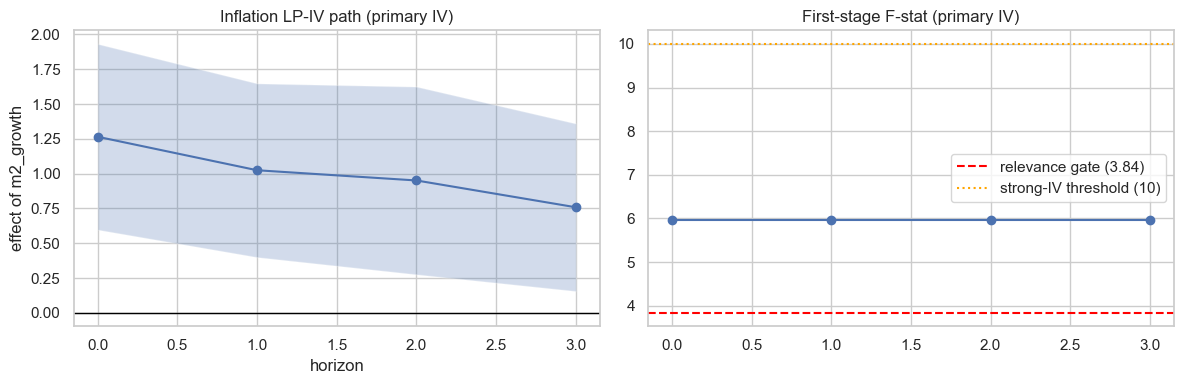

In [5]:
infl = primary[primary['outcome'] == 'inflation'].sort_values('horizon')
gdp = primary[primary['outcome'] == 'gdp_growth'].sort_values('horizon')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(infl['horizon'], infl['coef_m2_growth'], marker='o')
ax[0].fill_between(infl['horizon'], infl['ci_low_95'], infl['ci_high_95'], alpha=0.25)
ax[0].axhline(0, color='black', linewidth=1)
ax[0].set_title('Inflation LP-IV path (primary IV)')
ax[0].set_xlabel('horizon')
ax[0].set_ylabel('effect of m2_growth')

ax[1].plot(infl['horizon'], infl['first_stage_stat'], marker='o')
ax[1].axhline(IV_RELEVANCE_CUTOFF, color='red', linestyle='--', label='relevance gate (3.84)')
ax[1].axhline(IV_STRONG_CUTOFF, color='orange', linestyle=':', label='strong-IV threshold (10)')
ax[1].set_title('First-stage F-stat (primary IV)')
ax[1].legend()
fig.tight_layout()
fig.savefig(OUT_DIR / '03_inflation_lp_and_first_stage.png', dpi=170)
plt.show()

In [6]:
summary = pd.DataFrame([
    {'metric': 'inflation_sig_horizons_5pct_unadjusted', 'value': int((infl['p_value'] < 0.05).sum())},
    {'metric': 'inflation_sig_horizons_5pct_holm',       'value': int((infl['p_value_holm'] < 0.05).sum())},
    {'metric': 'gdp_sig_horizons_5pct',                  'value': int((gdp['p_value'] < 0.05).sum())},
    {'metric': 'inflation_min_first_stage_stat_primary', 'value': float(infl['first_stage_stat'].min())},
    {'metric': 'inflation_relevance_gate_all_horizons',  'value': bool((infl['first_stage_stat'] > IV_RELEVANCE_CUTOFF).all())},
    {'metric': 'inflation_strong_iv_all_horizons',       'value': bool((infl['first_stage_stat'] >= IV_STRONG_CUTOFF).all())},
    {'metric': 'fixed_sample_rows',                      'value': int(fixed_mask.sum())},
])
display(summary)

,metric,value
0,inflation_sig_horizons_5pct_unadjusted,4
1,inflation_sig_horizons_5pct_holm,4
2,gdp_sig_horizons_5pct,0
3,inflation_min_first_stage_stat_primary,5.96317
4,inflation_relevance_gate_all_horizons,True
5,inflation_strong_iv_all_horizons,False
6,fixed_sample_rows,3382


In [7]:
# IT stratification: first stage collapses in both subgroups.
# adopters F=2.61, never-adopters F=1.99 — both below IV_RELEVANCE_CUTOFF=3.84.
# Archived for completeness; do not interpret these coefficients.
strat_rows = []
for group in ['adopter', 'never_adopter']:
    m = fixed_mask & (lp_panel['it_group'] == group)
    for h in HORIZONS['inflation']:
        row = run_lp_iv(lp_panel, 'inflation', h, 'instrument_m2_external_level', m)
        row['it_group'] = group
        strat_rows.append(row)
strat_table = pd.DataFrame(strat_rows).sort_values(['it_group', 'horizon']).reset_index(drop=True)
display(strat_table[['it_group', 'horizon', 'coef_m2_growth', 'std_error', 'p_value', 'nobs', 'first_stage_stat']])

,it_group,horizon,coef_m2_growth,std_error,p_value,nobs,first_stage_stat
0,adopter,0,0.800368,0.282577,0.004620,762,2.614335
1,adopter,1,0.826972,0.291621,0.004571,762,2.614335
2,adopter,2,0.700853,0.262897,0.007679,762,2.614335
3,adopter,3,0.572987,0.294554,0.051742,762,2.614335
4,never_adopter,0,1.703300,0.836397,0.041703,2620,1.991766
5,never_adopter,1,1.304249,0.716413,0.068679,2620,1.991766
6,never_adopter,2,1.275352,0.821995,0.120774,2620,1.991766
7,never_adopter,3,1.006940,0.691843,0.145546,2620,1.991766


In [8]:
lp_table.to_csv(OUT_DIR / '03_lp_iv_all_results.csv', index=False)
primary.to_csv(OUT_DIR / '03_lp_iv_primary_results.csv', index=False)
alt.to_csv(OUT_DIR / '03_lp_iv_alt_results.csv', index=False)
strat_table.to_csv(OUT_DIR / '03_lp_iv_it_stratified.csv', index=False)
summary.to_csv(OUT_DIR / '03_interpretation_metrics.csv', index=False)
print('Saved outputs to:', OUT_DIR)

Saved outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/04_current_results/tables/short_run_lp


### Main takeaway

**Primary instrument (instrument_m2_external_level):**
- First-stage F = 5.96. Above the relevance gate (3.84) but below the **canonical** strong-IV threshold (10). Directional evidence only.
- Inflation LP-IV coefficients are positive and significant at h=0 to h=3, both unadjusted and Holm-corrected.
- GDP short-run response (h=0) is not significant.

**Alt instrument (instrument_m2_l1):**
- First-stage F = 16.29. Mechanically strong first stage after cleaned lag alignment, but lagged money is not credible enough as an excluded instrument for headline identification. Appendix sensitivity only.

**IT stratification:**
- First stage collapses in both subgroups: adopters F=2.61, never-adopters F=1.99. Both below relevance gate.
- The IT-split table is archived but uninformative.
- Reasons include that limited number of IT adopter used, and also the endogeneity problem: IT adopters experienced high inflation in the past.